# Analyse Embeddings

# Imports

In [1]:
from adjustText import adjust_text
from itertools import combinations
import networkx as nx
import numpy as np
import pandas as pd
from pathlib import Path
import pickle
from scipy.stats import spearmanr
from tqdm import tqdm as tqdm
import seaborn as sns
import matplotlib.pyplot as plt

import umap.umap_ as umap

c:\Users\roman\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Directories

In [2]:
# Define current directory
cwd = Path.cwd()
# Define DATA directory
DATA = cwd.parents[1]/'data'/'canada'

# Define INPUT directory
INPUT = DATA / 'input'

# Define OUTPUT directory
OUTPUT = DATA / 'output'

# Define CONTEXT directory
CONTEXT = OUTPUT / 'context_graphs'

# Define RNASEQ directory
RNASEQ = CONTEXT / 'rnaseq'

# Define CID directory
CID = CONTEXT / 'cid'

# Define MEAN directory
MEAN = CONTEXT / 'mean'

# Functions

## General

In [3]:
def file_to_list(path):
    '''
    Converts a .txt file to a list
    '''

    with open(f'{path}', 'r', encoding = 'utf-8') as f:
        list_file = [line.strip() for line in f]
    
    return list_file

def list_to_file(path, data):
      '''
      Saves a list or set to a .txt file with no header.
      '''

      with open(path, 'w') as f:
            for item in sorted(data):
                  f.write(f'{item}\n')

def pickle_load(path: str, report: bool = False):
    '''
    Loads pickled data.
    '''

    with open(path, 'rb') as f:
        data = pickle.load(f)

    if report == True:
        if type(data) == nx.Graph:
            num_nodes = len(data.nodes)
            num_edges = len(data.edges)
            print('>> pickle_load')
            print(f'Pickled graph loaded w/ {num_nodes:,} nodes and {num_edges:,} edges')
            print()
        else:
            print('>> pickle_load')
            print(f'Pickled file loaded')
            print()

    return data

def pickle_save(path: str, data, report: bool = False):
    '''
    Pickles data.
    '''

    with open(path, 'wb') as f:
        pickle.dump(data, f)

    if report == True:
        if type(data) == nx.Graph:
            num_nodes = len(data.nodes)
            num_edges = len(data.edges)
            print('>> pickle_save')
            print(f'Graph w/ {num_nodes:,} nodes and {num_edges:,} edges pickled')
        else:
            print('>> pickle_save')
            print(f'Data pickled')
            print()

# Analysis

## uMAP

In [4]:
# Load perturbagen info
df_perturbagen_info = pd.read_csv(OUTPUT / 'df_perturbagen_info.csv')
# Show data
df_perturbagen_info.head()

,perturbagen_id,perturbagen_name
0,DMSO,DMSO
1,BRD-A03772856,BRD-A03772856
2,BRD-A19037878,trichostatin-a
3,BRD-A19500257,geldanamycin
4,BRD-A34037822,KUC107191N


In [5]:
# Load embeddings
list_emb = pickle_load(OUTPUT / 'list_emb.pkl')
# Load list_pyg
list_pyg = pickle_load(OUTPUT / 'list_pyg.pkl')

# Stack embeddings
emb_stack = np.stack(list_emb, axis = 0)
# Generate mean consensus embedding
consensus_emb = emb_stack.mean(axis = 0)

c:\Users\roman\AppData\Local\Programs\Python\Python310\lib\site-packages\torch_geometric\typing.py:68: UserWarning: An issue occurred while importing 'pyg-lib'. Disabling its usage. Stacktrace: [WinError 127] The specified procedure could not be found
  warnings.warn(f"An issue occurred while importing 'pyg-lib'. "
c:\Users\roman\AppData\Local\Programs\Python\Python310\lib\site-packages\torch_geometric\typing.py:86: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: [WinError 127] The specified procedure could not be found
  warnings.warn(f"An issue occurred while importing 'torch-scatter'. "
c:\Users\roman\AppData\Local\Programs\Python\Python310\lib\site-packages\torch_geometric\typing.py:97: UserWarning: An issue occurred while importing 'torch-cluster'. Disabling its usage. Stacktrace: [WinError 127] The specified procedure could not be found
  warnings.warn(f"An issue occurred while importing 'torch-cluster'. "
c:\Users\roman\AppData\Lo

In [6]:
# Run uMAP embeddings
umap_embed = umap.UMAP(metric = 'cosine').fit_transform(consensus_emb)
# Extract graph data
graph_ids = [graph.name for graph in list_pyg]
graph_timepoints = [graph.timepoint for graph in list_pyg]

# Convert to dataframe
df_umap = pd.DataFrame(umap_embed, columns = ['x', 'y'])
df_umap['perturbagen_id'] = graph_ids
df_umap['timepoint'] = graph_timepoints

# Merge
df_umap = pd.merge(df_umap, df_perturbagen_info, how = 'left', on = 'perturbagen_id')
df_umap['perturbagen_name'] = df_umap['perturbagen_name'].fillna(df_umap['perturbagen_id'])

# Show data
df_umap.head()

,x,y,perturbagen_id,timepoint,perturbagen_name
0,2.141124,1.224950,Halo,6H,Halo
1,2.185443,-0.837944,Nita,6H,Nita
2,2.154133,-0.578906,Paro,6H,Paro
3,5.109277,8.791830,BRD-A00993607,6H,alprenolol
4,5.322343,6.544006,BRD-A02710418,6H,meptazinol


## Plot uMAP

In [7]:
# Load statin list
list_statins = file_to_list(OUTPUT / 'list_statin_ids.txt')
# Load opioid list
list_opioids = file_to_list(OUTPUT / 'list_opioid_ids.txt')
# Load profen list
list_profens = file_to_list(OUTPUT / 'list_profen_ids.txt')
# Load hdac list
list_hdac = file_to_list(OUTPUT / 'list_hdac_ids.txt')

In [8]:
# Convert IDs to names
list_statin_names = df_perturbagen_info['perturbagen_name'][df_perturbagen_info['perturbagen_id'].isin(list_statins)].values.tolist()
list_opioid_names = df_perturbagen_info['perturbagen_name'][df_perturbagen_info['perturbagen_id'].isin(list_opioids)].values.tolist()
list_profen_names = df_perturbagen_info['perturbagen_name'][df_perturbagen_info['perturbagen_id'].isin(list_profens)].values.tolist()
list_hdac_names = df_perturbagen_info['perturbagen_name'][df_perturbagen_info['perturbagen_id'].isin(list_hdac)].values.tolist()

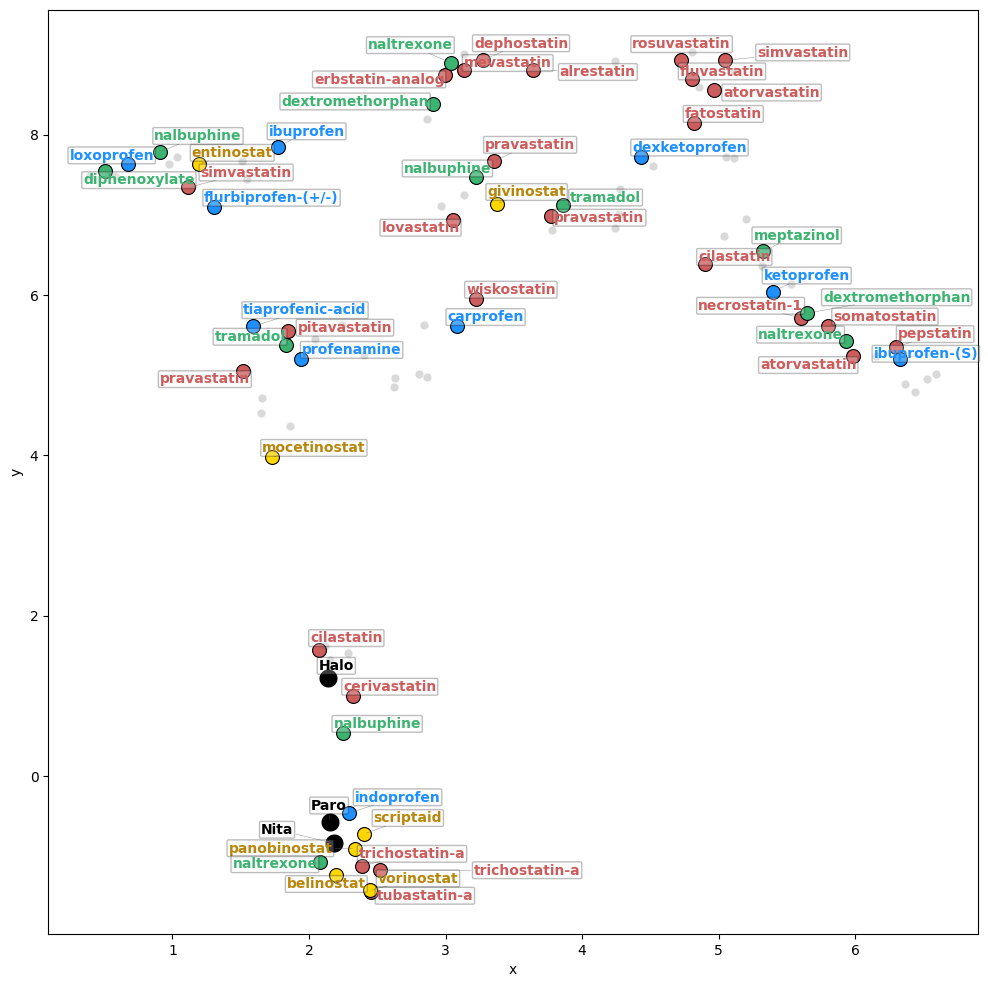

In [9]:
# Define treatment list
list_treat = ['Halo', 'Nita', 'Paro'] 

# Plot
plt.figure(figsize = (12,12))
sns.scatterplot(df_umap, x = 'x', y = 'y', color = 'dimgrey', alpha = 0.25)
sns.scatterplot(df_umap[df_umap['perturbagen_name'].isin(list_treat)], x = 'x', y = 'y', color = 'black', s = 200)
#sns.scatterplot(df_umap[df_umap['perturbagen_name'].str.contains('statin')], x = 'x', y = 'y', color = 'indianred', s = 100, edgecolor = 'black')
sns.scatterplot(df_umap[df_umap['perturbagen_name'].isin(list_statin_names)], x = 'x', y = 'y', color = 'indianred', s = 100, edgecolor = 'black')
sns.scatterplot(df_umap[df_umap['perturbagen_name'].isin(list_opioid_names)], x = 'x', y = 'y', color = 'mediumseagreen', s = 100, edgecolor = 'black')
sns.scatterplot(df_umap[df_umap['perturbagen_name'].isin(list_profen_names)], x = 'x', y = 'y', color = 'dodgerblue', s = 100, edgecolor = 'black')
sns.scatterplot(df_umap[df_umap['perturbagen_name'].isin(list_hdac_names)], x = 'x', y = 'y', color = 'gold', s = 100, edgecolor = 'black')

list_text = []
seen_points = set()   # prevent exact duplicates only

for idx, row in df_umap.iterrows():
    drug = row['perturbagen_name']
    x, y = row['x'], row['y']

    # Skip points that are not in any category
    if (
        drug not in list_treat and
        drug not in list_statin_names and
        drug not in list_opioid_names and
        drug not in list_profen_names and
        drug not in list_hdac_names
    ):
        continue

    # Prevent duplicate label if exact same coordinate/name repeats
    key = (drug, x, y)
    if key in seen_points:
        continue
    seen_points.add(key)

    # Color logic
    if drug in list_treat:
        label_color = 'black'
    elif drug in list_statin_names:
        label_color = 'indianred'
    elif drug in list_opioid_names:
        label_color = 'mediumseagreen'
    elif drug in list_profen_names:
        label_color = 'dodgerblue'
    elif drug in list_hdac_names:
        label_color = 'darkgoldenrod'
    else:
        label_color = 'black'

    # Label style
    label_style = {
        'fontsize': 10,
        'alpha': 1,
        'weight': 'bold',
        'color': label_color,
        'ha': 'center',
        'va': 'bottom',
        'bbox': {
            'facecolor': 'whitesmoke',
            'alpha': 0.25,
            'edgecolor': 'black',
            'boxstyle': 'round, pad=0.1'
        }
    }

    list_text.append(
        plt.text(x, y, drug, **label_style)
    )

# Adjust text positions
adjust_text(list_text, arrowprops=dict(arrowstyle='-', color='dimgrey', lw=0.25));